In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from ReadParticle import read_particle_frames

filenames = ['particles_1mm.txt']
# filenames = ['particles_1mm.txt', 'particles_3mm.txt', 'particles_4mm.txt', 'particles_5mm.txt',
#              'particles_7mm.txt', 'particles_1cm.txt', 'particles_5cm.txt', 'particles_10cm.txt']

datasets = []
# Read particle data
for file in filenames:
    
    Np_seq, time, r_dust, data_p = read_particle_frames(file)
    dataset = {}
    dataset['Np_seq'] = Np_seq
    dataset['time'] = time
    dataset['r_dust'] = r_dust
    dataset['data_p'] = data_p

    datasets.append(dataset)

num_datasets = len(datasets)

processing completed!


In [2]:
i = 0                # specify a dataset
target_day = 131.29  # specify targetted day
target_seconds = target_day * 86400.
t_idx = np.searchsorted(datasets[i]['time'], target_seconds, side="left")

p_t = datasets[i]['data_p'][t_idx]
day = datasets[i]['time'][t_idx] / 86400.

# matrix convert vector from 'Sun Body Center' to 'Didymos System Barycenter'
SBC_rotate_DSB = np.array([[-0.703595792353257, -0.710438191316344, 0.015183454875444],
                          [ 0.702824020343859, -0.692584740738747,  0.16237232930379 ],
                          [-0.104839674791979,  0.124915784491013,  0.986612735258626]])

In [3]:
# sky north vector and convert it to 'Didymos System Barycenter' frame
sky_north = np.array([0, 0, 1])
r_sky_north = np.dot(SBC_rotate_DSB, sky_north.T)

# position vector
r_sun = p_t[2, 1:4]    # [x, y, z] of the Sun
r_earth = p_t[3, 1:4]  # [x, y, z] of the Earth   (as a proxy of HST)
r_dust = p_t[4:, 1:4]  # [x, y, z] of all dust particles

In [4]:
# Project particles on a viewing plane

# calculate the two basis vectors of the projection plane
l1 = np.cross(r_sky_north, r_earth)
l2 = np.cross(r_earth, l1)
l1 = l1 / np.linalg.norm(l1)
l2 = l2 / np.linalg.norm(l2)

# create an array to record coordinates of particles projected onto the plane, and its angle deviated from the honrizontal line.
p_projected = np.zeros((len(p_t),3), dtype=float)
p_projected[:, 0] = p_t[:, 0]                  # copy the column of particle ID
p_projected[:, 1] = np.dot(p_t[:, 1:4], l1)    # x coordinate
p_projected[:, 2] = np.dot(p_t[:, 1:4], l2)    # y coordinate

In [5]:
# Calculate phase angle of dust particles

# Compute vectors
vec_sun = r_sun - r_dust      # Vectors from dust particles to Sun 
vec_earth = r_earth - r_dust  # Vectors from dust particles to Earth

# Compute norms
norm_sun = np.linalg.norm(vec_sun, axis=1)  # Magnitudes of Sun vectors
norm_earth = np.linalg.norm(vec_earth, axis=1)  # Magnitudes of Earth vectors

# Compute dot products
dot_product = np.einsum('ij,ij->i', vec_sun, vec_earth)  # Dot product of Sun and Earth vectors

# Compute phase angles
cos_theta = dot_product / (norm_sun * norm_earth)      # cosine of angle between two vectors
mu = - np.clip(cos_theta, -1.0, 1.0)             # cosine of scattering phase angle

In [29]:
import miepython as mie

I0 = 1            # incident solar flux at the particle location
m = 1.5 - 1j      # refractive index of sphere
r = 1e-3          # m radius of sphere
lambda0 = 500e-9  # m wavelength in vacuum
x = 2*np.pi*r/lambda0

qext, qsca, qback, g = mie.efficiencies(m, 2*r, lambda0)

# print("The extinction efficiency  is %.3f" % qext)
# print("The scattering efficiency  is %.3f" % qsca)
# print("The backscatter efficiency is %.3f" % qback)
# print("The scattering anisotropy  is %.3f" % g)

P_func = mie.i_unpolarized(m, x, mu)        # check how phase function is normalized.

I_sc = I0 * qsca * P_func

# --- Normalize intensity to 0–1 for alpha ---
alpha_vals = I_sc / np.max(I_sc)
#alpha_vals = np.clip(alpha_vals, 0.05, 1.0)

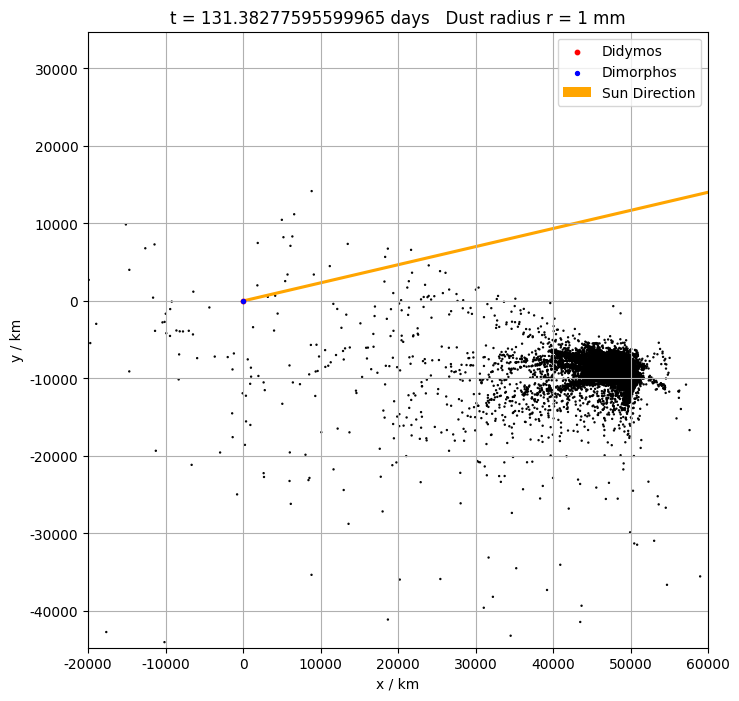

In [30]:
from matplotlib.ticker import FuncFormatter

axis_lims = [-20000e3, 60000e3, -20000e3, 10000e3]    # m

# Convert length unit for axis labels
def m_to_km(x, _):
    return f'{x / 1e3:.0f}'

# Create a new figure for this frame
fig, ax = plt.subplots(figsize=(8, 8))

# plot Didymos and Dimorphos
ax.scatter(p_projected[0, 1], p_projected[0, 2], c='red', s=10, zorder=3, label='Didymos')
ax.scatter(p_projected[1, 1], p_projected[1, 2], c='blue', s=8, zorder=3, label='Dimorphos')

# plot dust particles
dust_sca = ax.scatter(p_projected[4:, 1], p_projected[4:, 2], c='k', s=0.5, alpha=1)

# To set individual alphas, you need to use RGBA colors
colors = np.zeros((len(I_sc), 4))  # RGBA
colors[:, 3] = alpha_vals  # only alpha, rest stays black

dust_sca.set_facecolors(colors)

# Plot Sun direction relative to Didymos System Barycenter
sun_x, sun_y = p_projected[2, 1], p_projected[2, 2]
sun_distance = (sun_x**2 + sun_y**2) ** 0.5
arrow_x = sun_x / sun_distance * (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
arrow_y = sun_y / sun_distance * (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
ax.quiver(0, 0, arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='orange', label='Sun Direction')

# Customize axis
ax.xaxis.set_major_formatter(FuncFormatter(m_to_km))
ax.yaxis.set_major_formatter(FuncFormatter(m_to_km))

# Determine axis limit
ax.axis('equal')
ax.set_xlim(axis_lims[0], axis_lims[1])
ax.set_ylim(axis_lims[2], axis_lims[3])
ax.set_xlabel('x / km')
ax.set_ylabel('y / km')
ax.grid()
ax.legend(loc='upper right')

# Set title
ax.set_title(f't = {day} days   Dust radius r = 1 mm')

# Save the frame as a PNG image
#frame_filename = os.path.join(output_dir, f"frame_{frame:04d}.png")
#plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

In [34]:
colors

array([[0.        , 0.        , 0.        , 0.99999993],
       [0.        , 0.        , 0.        , 0.99999993],
       [0.        , 0.        , 0.        , 0.99999992],
       ...,
       [0.        , 0.        , 0.        , 0.99999994],
       [0.        , 0.        , 0.        , 0.99999993],
       [0.        , 0.        , 0.        , 0.99999993]])